In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Load data
df = pd.read_csv('../data/raw/data.csv')

# Separate reading columns
reading_cols = [col for col in df.columns 
                if col not in ['CONS_NO', 'FLAG']]

print("✅ Data loaded!")
print(f"Customers: {df.shape[0]}")
print(f"Reading days: {len(reading_cols)}")

✅ Data loaded!
Customers: 42372
Reading days: 1034


In [6]:
# Create feature dataframe
features = pd.DataFrame()

# Keep ID and label
features['CONS_NO'] = df['CONS_NO']
features['FLAG'] = df['FLAG']

readings = df[reading_cols]

# === BASIC STATISTICAL FEATURES ===
features['mean_consumption']   = readings.mean(axis=1)
features['std_consumption']    = readings.std(axis=1)
features['max_consumption']    = readings.max(axis=1)
features['min_consumption']    = readings.min(axis=1)
features['median_consumption'] = readings.median(axis=1)
features['skewness']           = readings.skew(axis=1)
features['kurtosis']           = readings.kurtosis(axis=1)

print("✅ Basic features done!")
print(features.shape)
features.head()

✅ Basic features done!
(42372, 9)


,CONS_NO,FLAG,mean_consumption,std_consumption,max_consumption,min_consumption,median_consumption,skewness,kurtosis
0,0387DD8A07E07FDA6271170F86AD9151,1,13.898342,8.843958,46.49,2.46,9.770,1.145385,0.572708
1,01D6177B5D4FFE0CABA9EF17DAFC2B84,1,0.000000,0.000000,0.00,0.00,0.000,0.000000,0.000000
2,4B75AC4F2D8434CFF62DB64D0BB43103,1,9.921390,6.822524,32.81,0.00,8.900,0.993721,1.738060
3,B32AC8CC6D5D805AC053557AB05F5343,1,14.612055,11.422513,52.76,0.40,12.735,0.666129,-0.095893
4,EDFC78B07BA2908B3395C4EB2304665E,1,8.249738,5.942354,43.43,0.85,6.265,2.592697,8.458808


In [7]:
# === THEFT SPECIFIC FEATURES ===
features['zero_reading_rate']  = (readings == 0).mean(axis=1)
features['negative_count']     = (readings < 0).sum(axis=1)
features['missing_rate']       = readings.isnull().mean(axis=1)
features['coeff_variation']    = (features['std_consumption'] / 
                                 (features['mean_consumption'] + 1e-5))

# Low consumption rate
features['low_reading_rate']   = (readings < 1).mean(axis=1)

print("✅ Theft features done!")
print(features.shape)

✅ Theft features done!
(42372, 14)


In [8]:
# === TREND FEATURES ===
mid = len(reading_cols) // 2
first_half  = readings.iloc[:, :mid]
second_half = readings.iloc[:, mid:]

features['first_half_mean']   = first_half.mean(axis=1)
features['second_half_mean']  = second_half.mean(axis=1)
features['consumption_trend'] = (features['second_half_mean'] - 
                                features['first_half_mean'])

# Percentile features
features['p25'] = readings.quantile(0.25, axis=1)
features['p75'] = readings.quantile(0.75, axis=1)
features['iqr'] = features['p75'] - features['p25']

print("✅ Trend features done!")
print(features.shape)
features.head()

✅ Trend features done!
(42372, 20)


,CONS_NO,FLAG,mean_consumption,std_consumption,max_consumption,min_consumption,median_consumption,skewness,kurtosis,zero_reading_rate,negative_count,missing_rate,coeff_variation,low_reading_rate,first_half_mean,second_half_mean,consumption_trend,p25,p75,iqr
0,0387DD8A07E07FDA6271170F86AD9151,1,13.898342,8.843958,46.49,2.46,9.770,1.145385,0.572708,0.000000,0,0.428433,0.636331,0.000000,14.828815,13.019901,-1.808914,7.1400,19.94,12.8000
1,01D6177B5D4FFE0CABA9EF17DAFC2B84,1,0.000000,0.000000,0.00,0.00,0.000,0.000000,0.000000,0.294004,0,0.705996,0.000000,0.294004,NaN,0.000000,NaN,0.0000,0.00,0.0000
2,4B75AC4F2D8434CFF62DB64D0BB43103,1,9.921390,6.822524,32.81,0.00,8.900,0.993721,1.738060,0.039652,0,0.749516,0.687657,0.039652,NaN,9.921390,NaN,7.4200,12.33,4.9100
3,B32AC8CC6D5D805AC053557AB05F5343,1,14.612055,11.422513,52.76,0.40,12.735,0.666129,-0.095893,0.000000,0,0.543520,0.781718,0.032882,5.390888,19.755215,14.364327,3.2775,23.28,20.0025
4,EDFC78B07BA2908B3395C4EB2304665E,1,8.249738,5.942354,43.43,0.85,6.265,2.592697,8.458808,0.000000,0,0.003868,0.720307,0.001934,6.238314,10.268988,4.030674,4.6525,9.86,5.2075


In [9]:
# Save engineered features
features.to_csv('../data/processed/features.csv', index=False)

print("✅ Features saved!")
print(f"Total features created: {features.shape[1] - 2}")
print(f"\nFeature names:")
for col in features.columns:
    if col not in ['CONS_NO', 'FLAG']:
        print(f"  → {col}")

✅ Features saved!
Total features created: 18

Feature names:
  → mean_consumption
  → std_consumption
  → max_consumption
  → min_consumption
  → median_consumption
  → skewness
  → kurtosis
  → zero_reading_rate
  → negative_count
  → missing_rate
  → coeff_variation
  → low_reading_rate
  → first_half_mean
  → second_half_mean
  → consumption_trend
  → p25
  → p75
  → iqr


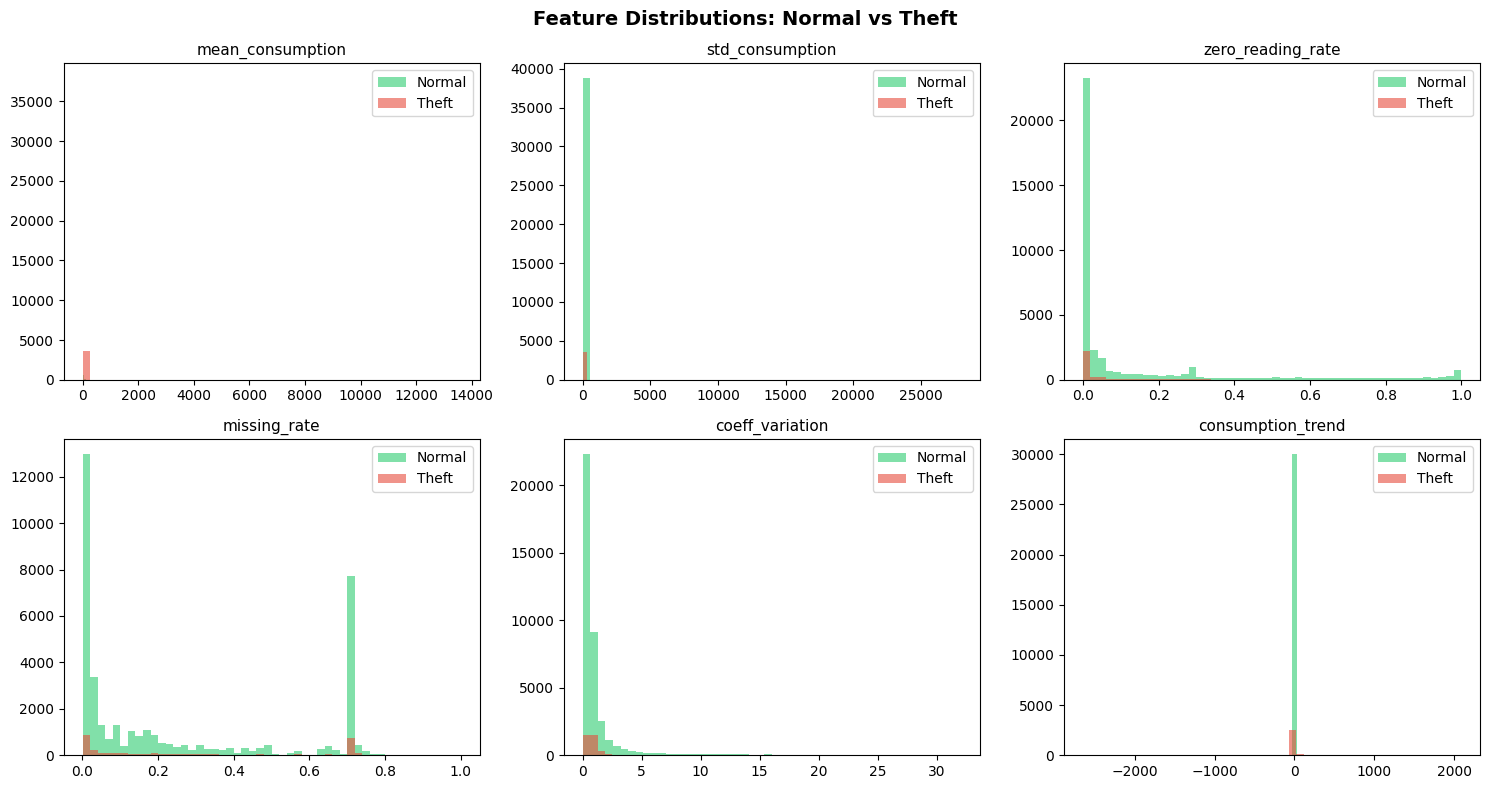

✅ Feature distribution plot saved!


In [10]:
# Compare features between Normal and Theft
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.ravel()

important_features = [
    'mean_consumption', 'std_consumption', 
    'zero_reading_rate', 'missing_rate',
    'coeff_variation', 'consumption_trend'
]

for i, feat in enumerate(important_features):
    normal = features[features['FLAG']==0][feat]
    theft  = features[features['FLAG']==1][feat]
    
    axes[i].hist(normal, bins=50, alpha=0.6, 
                 color='#2ecc71', label='Normal')
    axes[i].hist(theft,  bins=50, alpha=0.6, 
                 color='#e74c3c', label='Theft')
    axes[i].set_title(feat, fontsize=11)
    axes[i].legend()

plt.suptitle('Feature Distributions: Normal vs Theft', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/processed/feature_distributions.png')
plt.show()
print("✅ Feature distribution plot saved!")

In [ ]:
# === ADVANCED FEATURES ===

# Consecutive zero days (powerful theft signal)
def max_consecutive_zeros(row):
    max_count = count = 0
    for val in row:
        if val == 0 or pd.isna(val):
            count += 1
            max_count = max(max_count, count)
        else:
            count = 0
    return max_count

print("Calculating consecutive zeros (takes 2-3 mins)...")
features['max_consec_zeros'] = df[reading_cols].apply(
    max_consecutive_zeros, axis=1)

# Ratio of max to mean (spike detection)
features['max_to_mean_ratio'] = (features['max_consumption'] / 
                                 (features['mean_consumption'] + 1e-5))

# Night vs day pattern (using first/last readings as proxy)
quarter = len(reading_cols) // 4
features['q1_mean'] = readings.iloc[:, :quarter].mean(axis=1)
features['q4_mean'] = readings.iloc[:, 3*quarter:].mean(axis=1)
features['q1_q4_ratio'] = (features['q1_mean'] / 
                           (features['q4_mean'] + 1e-5))

# Sudden change detection
features['sudden_change'] = abs(features['second_half_mean'] - 
                                features['first_half_mean']) / (
                                features['mean_consumption'] + 1e-5)

print("✅ Advanced features added!")
print(f"Total features now: {features.shape[1] - 2}")

# Save updated features
features.to_csv('../data/processed/features.csv', index=False)
print("✅ Saved!")